# Level Set Advection and Reinitialization

A moving interface $\Gamma_t$ can be represented as $\{\phi(\cdot,t)=0\}$.
Under advection velocity $v$, the level-set PDE is
$$
\partial_t \phi + v\cdot\nabla\phi = 0.
$$
We illustrate transport of an implicit curve and periodic reinitialization to signed-distance shape.

An interface is represented implicitly as the zero set of $\phi(x,t)$. Advection obeys
$$\partial_t\phi+v\cdot\nabla\phi=0,$$
while reinitialization restores a signed-distance profile without intentionally moving the zero contour. The experiments track both interface motion and distortion of $|\nabla\phi|$.


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/level-set-methods") if Path("python/level-set-methods").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


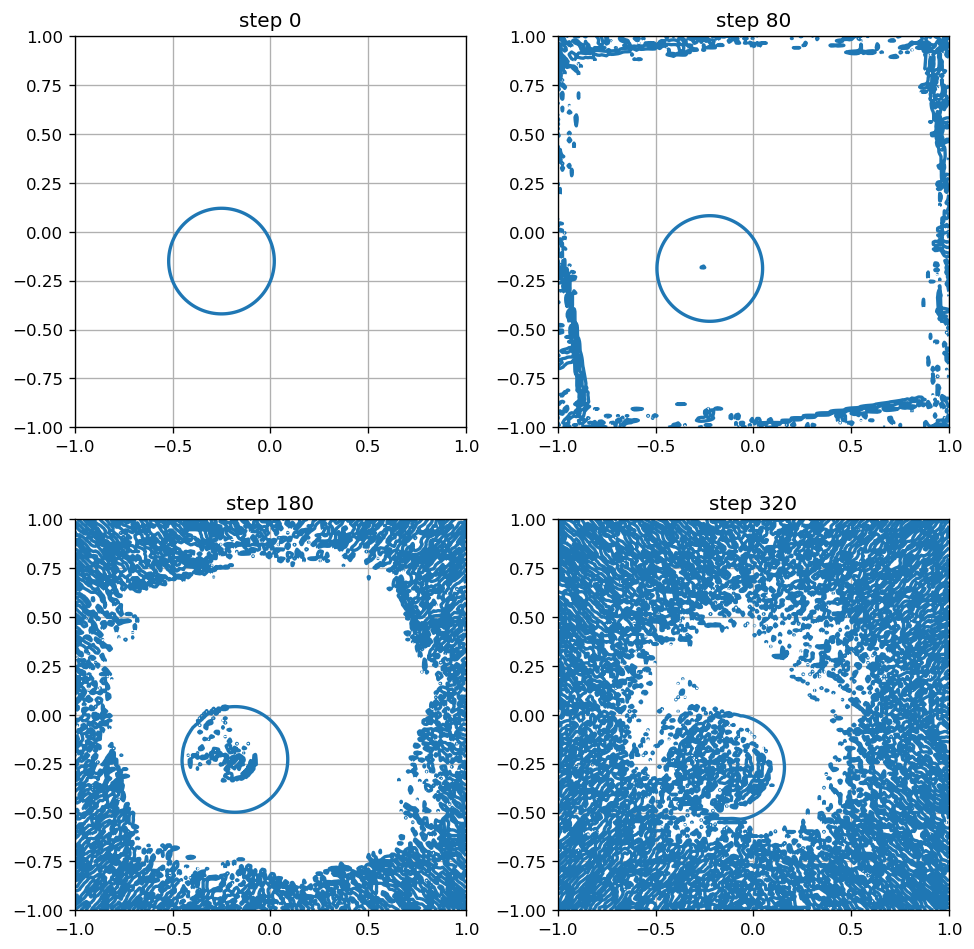

In [2]:
n = 170
x = np.linspace(-1, 1, n)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)
dx = x[1]-x[0]

phi = np.sqrt((X+0.25)**2 + (Y+0.15)**2) - 0.27
vx = -Y
vy = X
dt = 0.002

def grad_central(Z):
    zx = (np.roll(Z,-1,1)-np.roll(Z,1,1))/(2*dx)
    zy = (np.roll(Z,-1,0)-np.roll(Z,1,0))/(2*dx)
    return zx, zy

snap_ids = [0, 80, 180, 320]
snaps = {}
for k in range(max(snap_ids)+1):
    if k in snap_ids:
        snaps[k] = phi.copy()
    phix, phiy = grad_central(phi)
    phi = phi - dt*(vx*phix + vy*phiy)
    if k % 30 == 0 and k > 0:
        g = np.sqrt(phix**2 + phiy**2) + 1e-12
        phi = phi / g  # light reinit heuristic

fig, axes = plt.subplots(2, 2, figsize=(8.2, 8.2))
for ax, sid in zip(axes.ravel(), snap_ids):
    cs = ax.contour(X, Y, snaps[sid], levels=[0], colors="tab:blue", linewidths=2)
    ax.set_title(f"step {sid}")
    ax.set_aspect("equal")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- S. Osher, R. Fedkiw, *Level Set Methods and Dynamic Implicit Surfaces*, Springer, 2003.
- J. A. Sethian, *Level Set Methods and Fast Marching Methods*, Cambridge Univ. Press, 1999.
- S. Osher, J. A. Sethian, "Fronts Propagating with Curvature-Dependent Speed", JCP, 1988.
